# Lesson 9.1 - Time Series Data Analysis

In this notebook, we explore the basic analysis of **time series data**.  
Time series are data in which each observation is associated with a **point in time**, and the **temporal order of observations matters**.

Time series analysis appears in many fields, for example:
- temperature measurements,
- stock prices,
- website traffic,
- sensor readings,
- daily, weekly, or monthly sales data.

Analyzing this type of data differs from working with traditional tabular datasets in several ways.  
Here, not only the magnitude of the values matters, but also **how they change over time**, and whether we can observe:
- **trend**,
- **seasonality**,
- **outliers**,
- or some kind of recurring pattern.

In this notebook, we will examine a few fundamental steps in handling and exploring time series data:
- converting the time column to the proper format,
- sorting observations by time,
- plotting time series,
- recognizing simple trends and patterns.

Our goal is not yet to build complex forecasting models, but to understand  
**what makes time series data different**, and how it can be analyzed thoughtfully.

## Brief Introduction to the Airline Passengers Dataset

In this notebook, we will use the well-known **Airline Passengers dataset**.  
This is a classic and frequently used time series dataset that shows how the **monthly number of international airline passengers** changed over time.

The dataset contains two columns:
- **Month**: the time point of the given month,
- **Passengers**: the number of passengers in that month.

This example is especially suitable for introducing the basics of time series analysis because it clearly shows:
- a long-term **trend**,
- repeating **seasonality**,
- and how values change from month to month.

In the next step, we will load the dataset from a `.csv` file available on GitHub and inspect the first few rows.

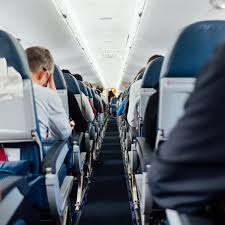

### Loading the Data

In [1]:
import pandas as pd

# Load the dataset from GitHub
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Convert the data

# Currently, the time column is just a string. Convert it to a proper datetime type.
df['date'] = pd.to_datetime(df['Month'])
df['month'] = df['date'].apply(lambda x: x.month)
df['year'] = df['date'].apply(lambda x: x.year)

# This is a VERY IMPORTANT step for seasonal_decompose.
df.set_index('date', inplace=True)

# Display the first 5 rows
print(df.head())

              Month  Passengers  month  year
date                                        
1949-01-01  1949-01         112      1  1949
1949-02-01  1949-02         118      2  1949
1949-03-01  1949-03         132      3  1949
1949-04-01  1949-04         129      4  1949
1949-05-01  1949-05         121      5  1949


### Visualizing the Time Series

Before applying any statistical or machine learning method, it is worth **looking at the series visually**.  
Even a simple line chart can reveal a lot about whether:
- there is an **upward or downward trend**,  
- **seasonality** can be observed (yearly, monthly, or weekly cycles),  
- and whether **outliers** or **noisy periods** occur.

One of the main characteristics of time series is that **they change as time passes**, so the temporal position of the data is essential for interpretation.

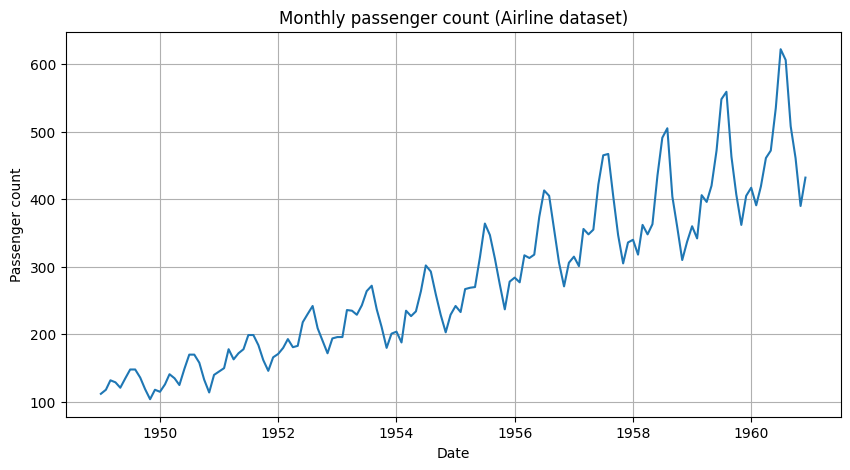

In [2]:
import matplotlib.pyplot as plt

# Simple line chart
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Passengers'])
plt.title('Monthly passenger count (Airline dataset)')
plt.xlabel('Date')
plt.ylabel('Passenger count')
plt.grid(True)
plt.show()

## What Do We See in the Plots?

- **Trend:** A clear long-term increase can be seen in the number of passengers.  
  This suggests that more and more people traveled by air over the years.

- **Seasonality:** Repeating yearly waves can be observed.  
  In the summer months (for example, July and August), passenger numbers are consistently higher, while they drop in winter.

- **Volatility:** The magnitude of the fluctuations increases over time.  
  The swings in the curve become larger, meaning passenger traffic is not only growing but also becoming more variable.

### Examining the Time Series by Year

Grouping the data by year helps us see the pattern of each individual year **side by side**, making it easier to notice whether peak periods behave similarly every year.

This approach helps with:
- understanding **seasonality** (yearly repetition),  
- recognizing **trend** (growth or decline) more easily,  
- and quickly comparing **beginning-of-year and end-of-year values**.

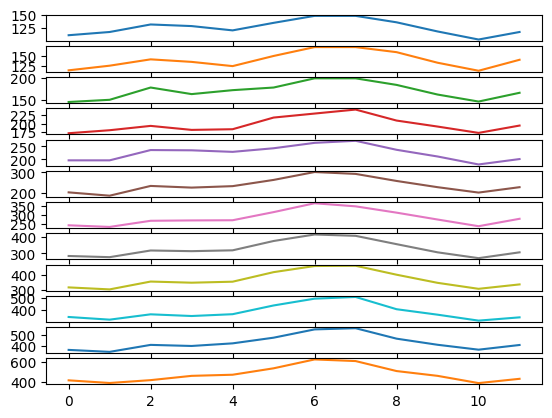

In [3]:
# Group by year
groups = df.groupby(pd.Grouper(freq='YE'))  # 'YE' = Annual grouping

# Split the data into separate years
years = pd.DataFrame()
for name, group in groups:
    years[name.year] = group.Passengers.values

# Plot each year separately
years.plot(subplots=True, legend=False)
plt.show()

## What Do We See in the Plots?

<strong>What do we see in the chart?</strong>

- Passenger numbers at the **beginning and end of the year** increase from year to year.  
- The **annual peak season** (summer months) appears every year, but the peak becomes higher over time.  
- The **overall pattern repeats**, while the **overall volume keeps increasing** - in other words, both trend and seasonality are present at the same time.

## Applying a Power Transformation to Time Series

A power transformation can be useful not only for traditional numerical data, but also for time series.

In some time series, as the overall level of the data increases, the size of the fluctuations also grows. In such cases, the later sections of the series show larger swings than the earlier ones.

This can be clearly seen in the *Airline Passengers* dataset:
- the number of passengers increases over the long term,
- and the amplitude of the yearly fluctuations increases as well.

In such situations, a power transformation can help:
- make the fluctuations more balanced,
- reveal the structure of the time series more clearly,
- and make the data visually easier to interpret.

In this example, we compare the original series with its **Box-Cox transformed** version.

It is important to note that the transformation does not change the order of the observations in time; instead, it changes the scale of the values so that certain properties of the time series become easier to observe.

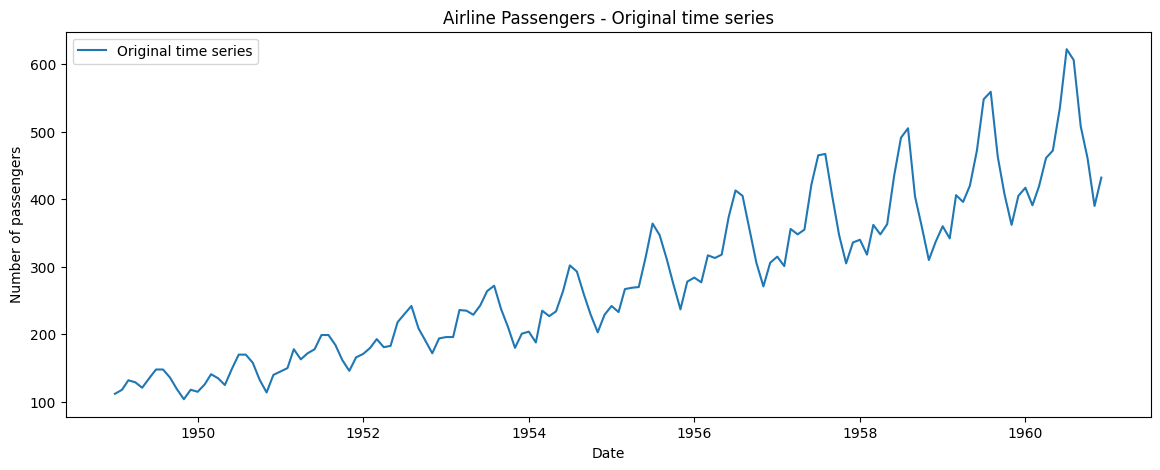

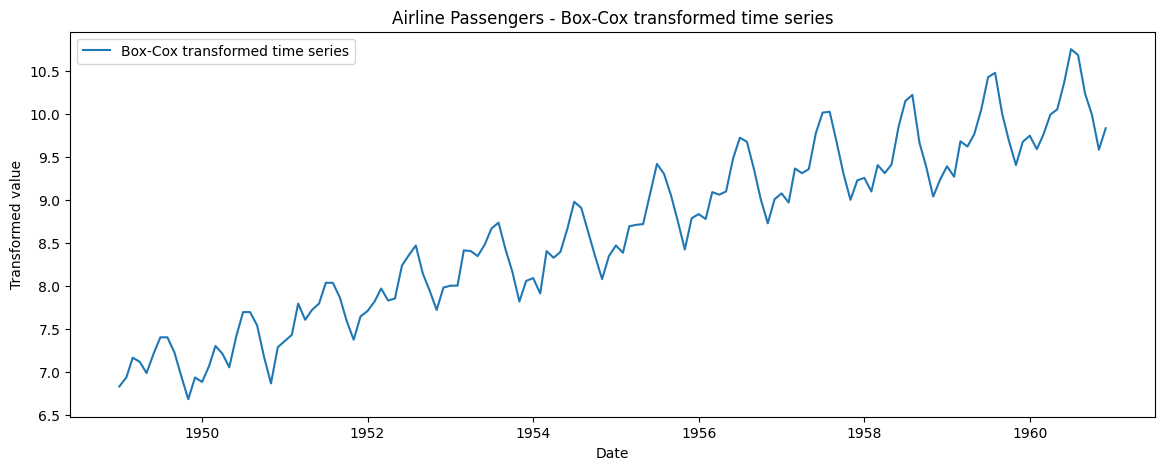

In [4]:
from scipy.stats import boxcox

# Box-Cox transformation
passengers_boxcox, lambda_value = boxcox(df["Passengers"])

# Create a new column
df["Passengers_boxcox"] = passengers_boxcox

# Plotting
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Passengers"], label="Original time series")
plt.title("Airline Passengers - Original time series")
plt.xlabel("Date")
plt.ylabel("Number of passengers")
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Passengers_boxcox"], label="Box-Cox transformed time series")
plt.title("Airline Passengers - Box-Cox transformed time series")
plt.xlabel("Date")
plt.ylabel("Transformed value")
plt.legend()
plt.show()

### Short Interpretation

- In the original time series, it is clearly visible that as passenger counts increase, the fluctuations also become larger.

- After the Box-Cox transformation, the fluctuations appear more balanced, so the seasonal pattern and the overall structure are often easier to examine.

This does not mean that the transformed series is "better" or "truer"; it simply means that, for certain analytical purposes, it has become easier to work with.

### Seasonal Decomposition (`seasonal_decompose`)

The goal of **seasonal decomposition** is to split a time series into three main components:

1. **Trend (T)** - the long-term direction (increase or decrease)  
2. **Seasonal component (S)** - a repeating cyclical pattern (for example, seasonal sales or travel behavior)  
3. **Random / residual component (R)** - the remaining noise not explained by the trend and seasonal components




<strong>Additive vs. Multiplicative Model</strong>

Depending on the structure of the time series, the components may **add together (additive)** or **multiply with each other (multiplicative)**.  
The difference lies in how the seasonal effect changes as the values of the time series increase.

| Model type | Formula | When do we use it? |
|----------------|--------|------------------|
| **Additive model** | Time series = Trend + Seasonal + Residual | When the seasonal deviation has a **constant magnitude** (for example, roughly the same fluctuation every year) |
| **Multiplicative model** | Time series = Trend x Seasonal x Residual | When the seasonal deviation is **proportional to the values** (for example, larger traffic leads to larger swings) |

<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b><strong>Observation:</strong></b><br>
In the <em>Airline Passengers</em> dataset, the seasonal effect increases together with passenger counts, so the <strong>multiplicative model</strong> is a better fit for the data.
</div>

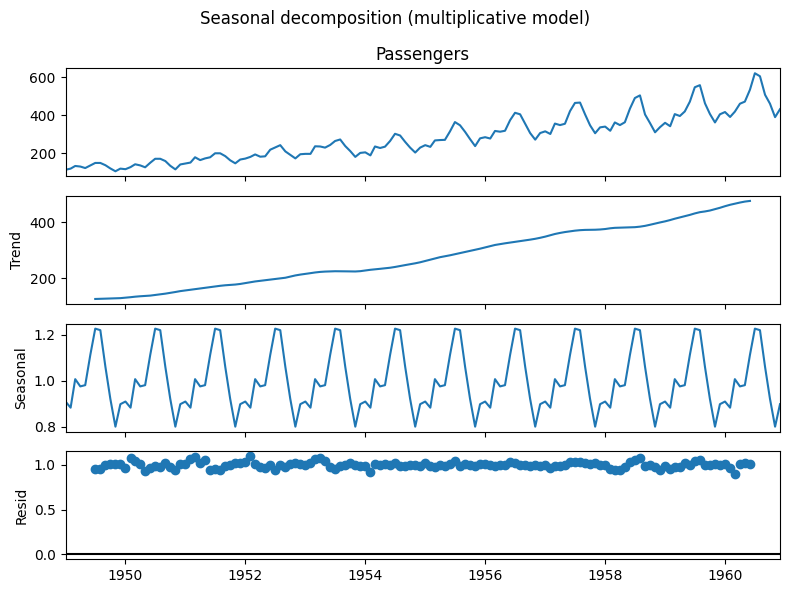

In [5]:
## Decomposition of the Airline Passengers Dataset
from statsmodels.tsa.seasonal import seasonal_decompose

# Multiplicative seasonal decomposition (for monthly data, period=12)
result = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

# Visualize the results
plt.rcParams.update({'figure.figsize': (8, 6)})
result.plot()
plt.suptitle("Seasonal decomposition (multiplicative model)")
plt.tight_layout()
plt.show()

### What Do We See in the Plots?

The decomposition consists of four parts:

1. **Original time series:**  
   The original passenger traffic over time.

2. **Trend component:**  
   The long-term increase - passenger counts become higher year by year.

3. **Seasonal component:**  
   The repeating yearly pattern - peaks in summer and declines in winter.

4. **Residual component:**  
   The remaining noise not explained by trend and seasonality.  
   These are smaller random fluctuations, for example the effects of special events.

#### Recognizing Seasonal Patterns (Visually and Statistically)

In time series, **repeating patterns** often occur - for example, sales may rise every summer,  
or demand may fall every winter.  
These **seasonal cycles** are among the easiest structures to identify visually.

<strong>Why is it important to recognize seasonality?</strong>

- Seasonality helps **improve forecasts** (for example, when a peak or decline is expected).  
- It allows the **normalization** of the data (for example, removing the effect of seasons).  
- It helps identify **anomalies**: if a month's value falls outside the usual range.

<Axes: title={'center': 'Passengers'}, xlabel='month'>

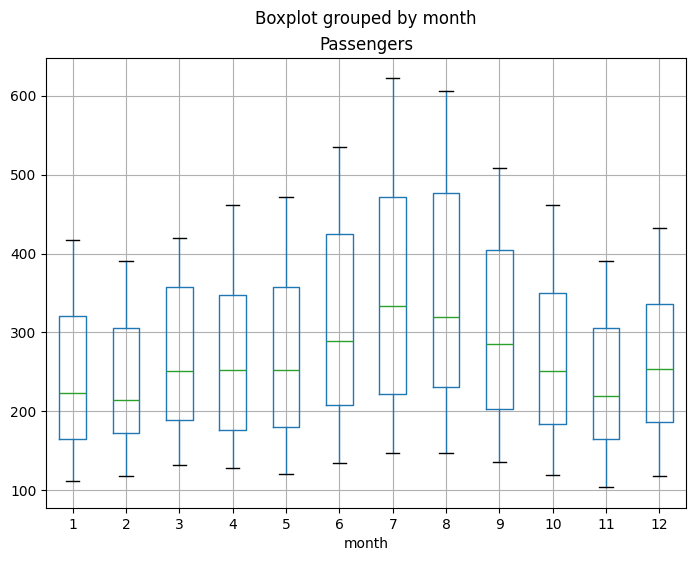

In [6]:
df.boxplot(column='Passengers', by='month')

### Visual Time Series Map (Heatmap)

A **visual time series map**, also called a **heatmap**, is one of the most effective ways  
to see both **yearly trends** and **monthly seasonality** within the same time series.

The idea is simple:  
we place the individual **years** next to each other as columns,  
and display the **months** vertically as rows.  
With the help of colors, it immediately becomes visible when the **busiest** and **weakest** periods occurred.

<strong>Why is this representation useful?</strong>

- **Recognizing seasonality:** repeating patterns (for example, growth in the summer months every year) are easy to spot.  
- **Examining trend:** as the years progress, the shade of the colors changes (lighter -> darker = increase).  
- **Identifying anomalies:** if a given month differs unusually from nearby values, it stands out immediately in color.

<Figure size 1000x600 with 0 Axes>

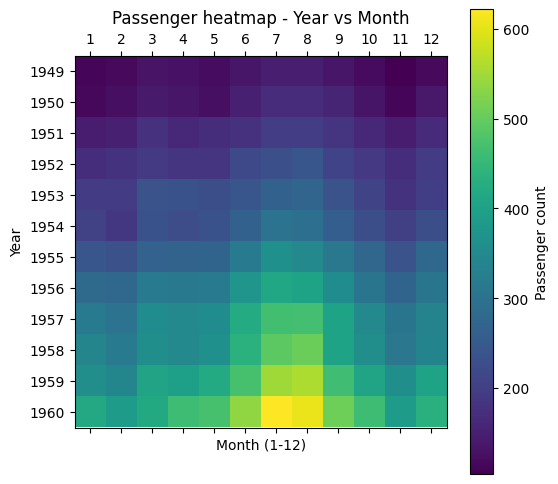

In [7]:
# Group data by year
groups = df.groupby(pd.Grouper(freq='YE'))     # 'YE' = Annual grouping

# Create a new DataFrame where each column contains the monthly values of one year
years = pd.DataFrame()
for name, group in groups:
    years[name.year] = group['Passengers'].values  # months as rows, years as columns

# Create a heatmap
plt.figure(figsize=(10, 6))
plt.matshow(years.T, interpolation=None)
plt.title("Passenger heatmap - Year vs Month")
plt.xlabel("Month (1-12)")
plt.ylabel("Year")
plt.xticks(ticks=range(12), labels=range(1, 13))
plt.yticks(ticks=range(len(years.columns)), labels=years.columns)
plt.colorbar(label="Passenger count")
plt.show()

#### Autocorrelation Function (ACF)

One of the most important tools in time series analysis is **autocorrelation**. **Autocorrelation** shows how similar the **current values of the series are to earlier shifted values (lags)**.

**What does the ACF measure?**

- ACF (Autocorrelation Function): the correlation of a time series **with itself at different lags**.  
- For example, if the autocorrelation at lag 1 is high, then the current value **strongly depends on the previous one**.
- If several lags are significant, then a **persistent relationship** or a **repeating pattern (seasonal effect)** may also be present.

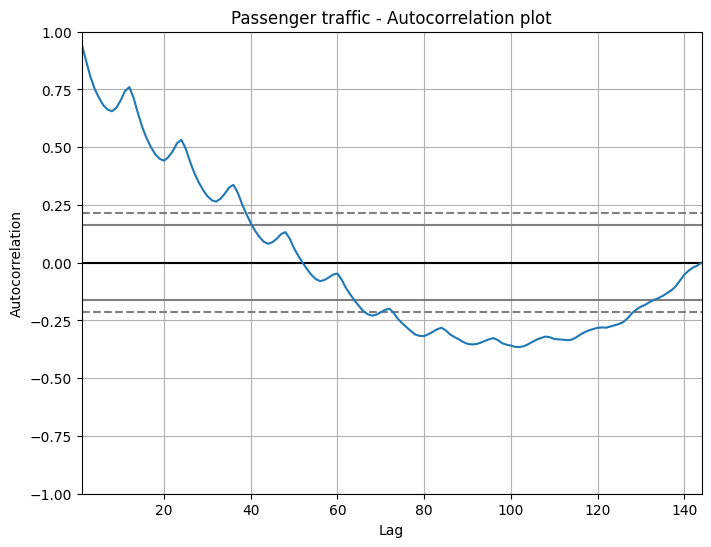

In [8]:
from pandas.plotting import autocorrelation_plot

# Create an autocorrelation plot
# Shows how strongly the values correlate at different lags
autocorrelation_plot(df['Passengers'])
plt.title('Passenger traffic - Autocorrelation plot')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

### What Do We See in the Plots?

- The autocorrelation **decreases gradually**,  
- then shows another spike around **lag ≈ 12** -> this suggests **yearly seasonality**,  
- This matches what we expected beforehand: the airport reaches recurring maxima and minima in a 12-month cycle.

### Why is this useful?

- Workforce planning
- Revenue forecasting
- and more

Of course, time series analysis and autocorrelation are much broader and more complex topics than this, but this is already enough to understand the basics.

### KDE Plot Split by Year

From the ACF, we could already see that 12-month lags are correlated.
Let us examine this a bit more closely using yearly distribution plots.

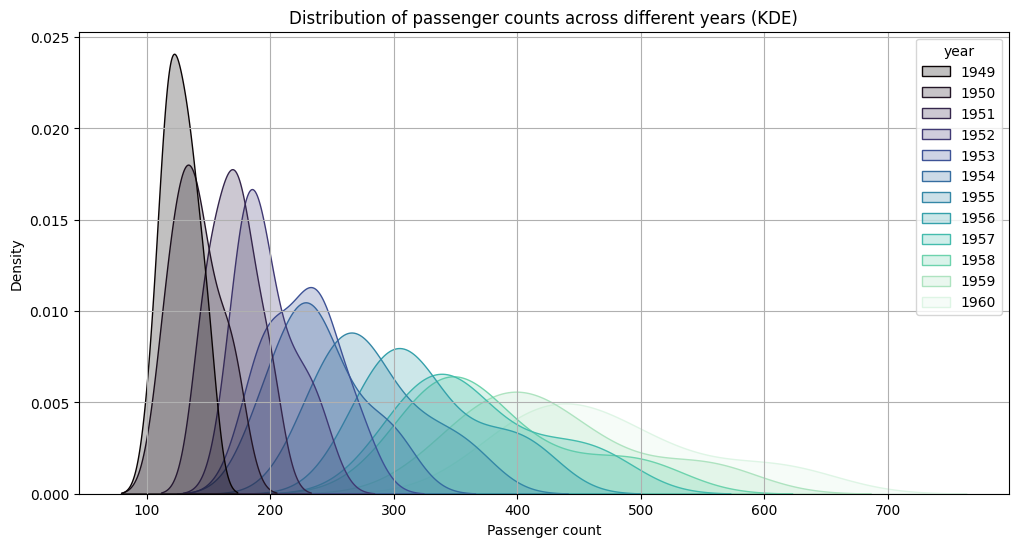

In [9]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Passengers', hue='year', fill=True, common_norm=False, palette='mako')
plt.title("Distribution of passenger counts across different years (KDE)")
plt.xlabel("Passenger count")
plt.ylabel("Density")
plt.grid(True)
plt.show()

### What Do We See in the Plots?

In the chart, we see the **year-by-year distribution (KDE)** of passenger counts.  
It is clearly visible that, as the years progress, the distribution **shifts further to the right** - that is, passenger counts gradually increase.  
At the same time, the distributions are **not symmetric**, but show a **right-skewed** shape.

### 2D KDE - Relationship Between Month and Passenger Count

The two-dimensional KDE (bivariate KDE) plot shows **in which months** passenger traffic was highest.  
The colors indicate density: **warmer colors (pink-red)** represent higher passenger counts and more frequent observations.

<strong>Interpretation:</strong>
- Passenger numbers are highest around the summer months (6-8), which indicates a seasonal effect.  
- In the winter months (1-2 and 11-12), passenger numbers are lower and fewer flights are taken.  
- The shape of the distribution clearly shows the **yearly cyclical pattern** in passenger traffic.

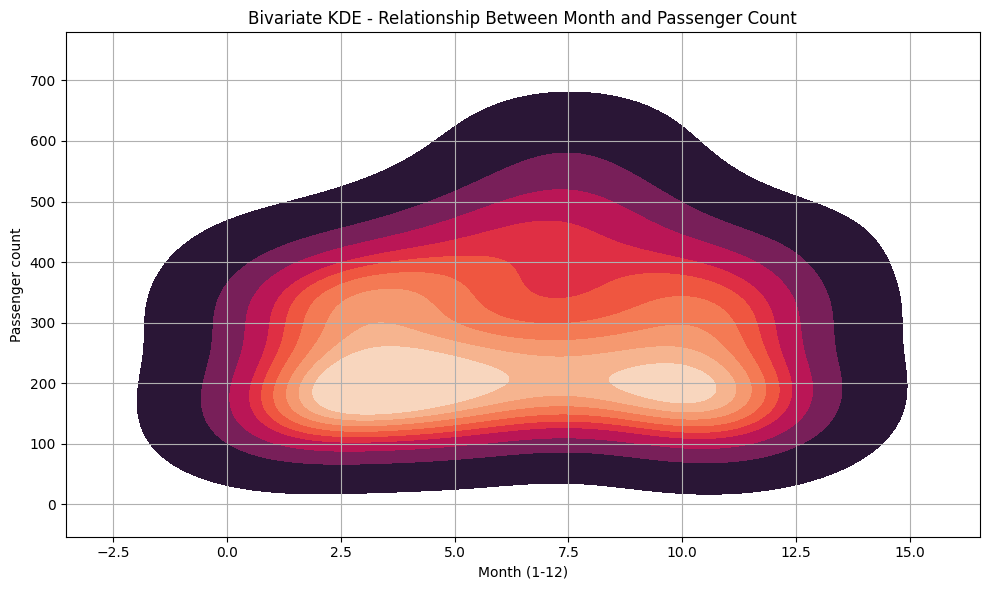

In [10]:
### 2D KDE (Bivariate KDE) - Month vs Passenger Count

# Bivariate KDE plot: month vs passenger count
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='month',
    y='Passengers',
    cmap="rocket",
    fill=True,
    thresh=0.02
)
plt.title("Bivariate KDE - Relationship Between Month and Passenger Count")
plt.xlabel("Month (1-12)")
plt.ylabel("Passenger count")
plt.grid(True)
plt.tight_layout()
plt.show()

### What Do We See in the Plot?

- Where the color is darker, the given month-passenger-count pairs occur more densely.

<strong>For example:</strong>
- Month: 7-8
- Passenger count: 400-600 -> the summer peak is clearly visible.

## Tasks

## Daily Minimum Temperatures Dataset

In this exercise set, we will work with the **Daily Minimum Temperatures** dataset.  
The dataset shows how the **daily minimum temperature** changed over time.

This is a classic time series dataset that is especially suitable for observing:
- changes over time,
- possible seasonal patterns,
- the behavior of daily data over a longer time span,
- and how time series visualizations and simple analyses help interpret the data.

The dataset contains two columns:
- **Date**: the date of the observation,
- **Temp**: the minimum temperature on that day.

In the next step, we will load the data, convert the time column to the proper date format, and prepare the dataset for time series analysis.

In [11]:
import pandas as pd

# Load the dataset from GitHub
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df_temp = pd.read_csv(url)

# Display the first 5 rows
print(df_temp.head())

# Convert the date column to datetime
df_temp["Date"] = pd.to_datetime(df_temp["Date"])

# Create additional time-based columns
df_temp["Year"] = df_temp["Date"].dt.year
df_temp["Month"] = df_temp["Date"].dt.month
df_temp["Month_name"] = df_temp["Date"].dt.month_name()

# Set the date column as index
df_temp = df_temp.set_index("Date")

# Display basic information
print(df_temp.info())
print(df_temp.head())

         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Temp        3650 non-null   float64
 1   Year        3650 non-null   int32  
 2   Month       3650 non-null   int32  
 3   Month_name  3650 non-null   object 
dtypes: float64(1), int32(2), object(1)
memory usage: 114.1+ KB
None
            Temp  Year  Month Month_name
Date                                    
1981-01-01  20.7  1981      1    January
1981-01-02  17.9  1981      1    January
1981-01-03  18.8  1981      1    January
1981-01-04  14.6  1981      1    January
1981-01-05  15.8  1981      1    January


In [12]:
df_temp

,Temp,Year,Month,Month_name
Date,,,,
1981-01-01,20.7,1981,1,January
1981-01-02,17.9,1981,1,January
1981-01-03,18.8,1981,1,January
1981-01-04,14.6,1981,1,January
1981-01-05,15.8,1981,1,January
...,...,...,...,...
1990-12-27,14.0,1990,12,December
1990-12-28,13.6,1990,12,December
1990-12-29,13.5,1990,12,December


### 1. Task - Basic Examination of the Time Series

Create a line chart of the daily minimum temperatures.

**Think about:**
- Is there a longer-term trend?
- Is there a repeating pattern?
- How noisy is the time series?

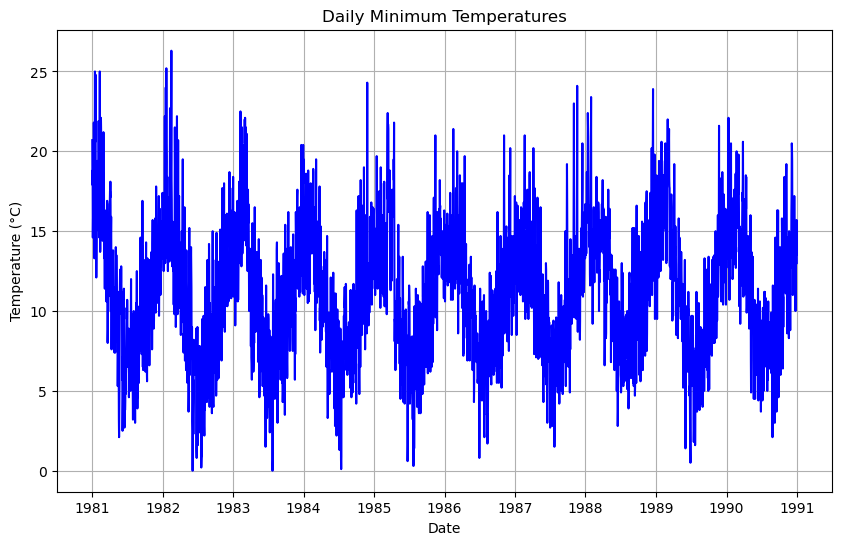

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df_temp = pd.read_csv(url)

df_temp["Date"] = pd.to_datetime(df_temp["Date"])

df_temp["Year"] = df_temp["Date"].dt.year
df_temp["Month"] = df_temp["Date"].dt.month
df_temp["Month_name"] = df_temp["Date"].dt.month_name()

df_temp = df_temp.set_index("Date")

# Plotting the daily minimum temperatures
plt.figure(figsize=(10, 6))
plt.plot(df_temp.index, df_temp["Temp"], color='blue')
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()


### 2. Task - Comparing Yearly Patterns
Examine how the daily minimum temperature changes across different years.

**Task:**
- Create at least one chart that helps compare the individual years.
- Observe how similar the years are to one another.

**Think about:**
- How similar is the shape of the curves across different years?
- What kind of seasonal behavior can be observed?

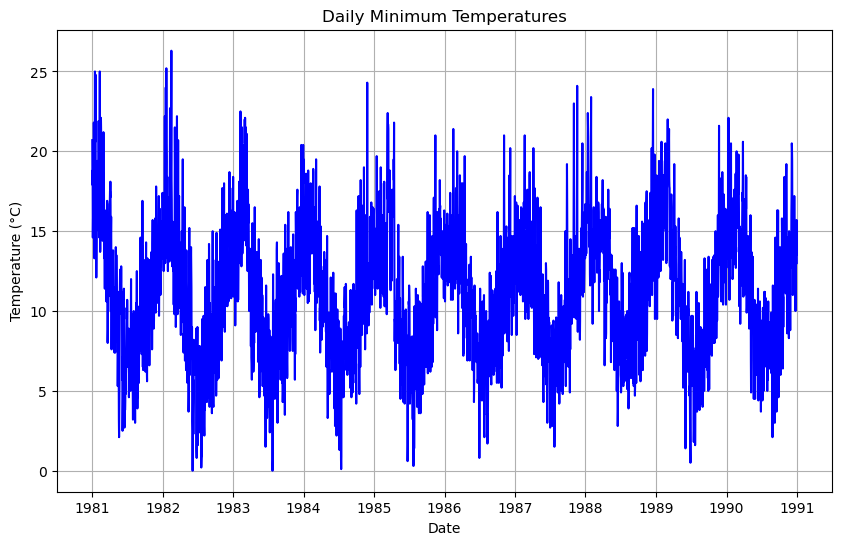

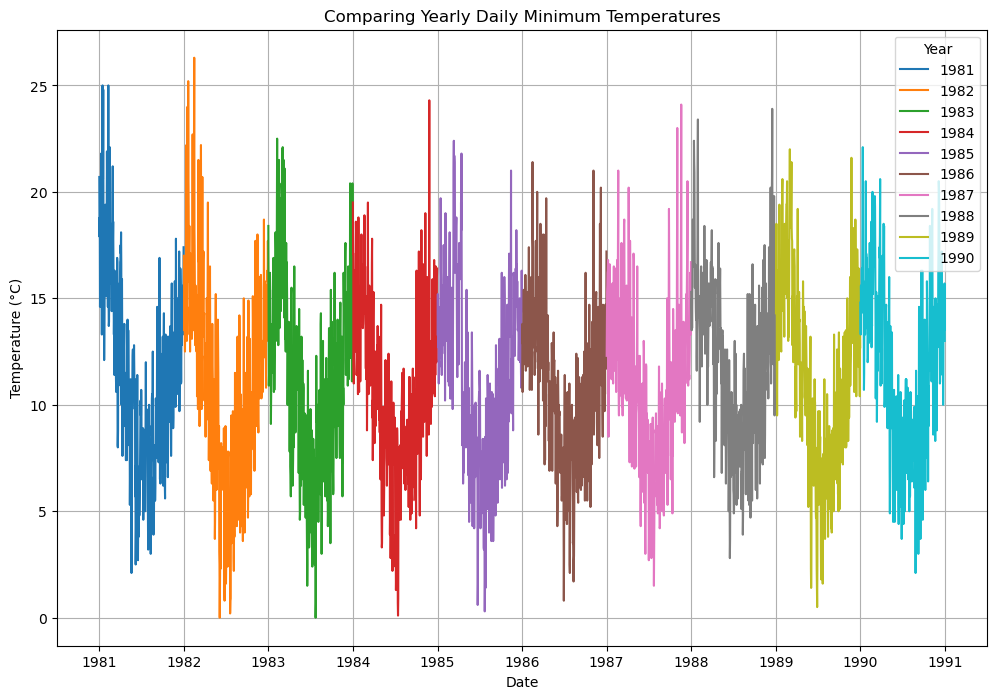

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df_temp = pd.read_csv(url)

df_temp["Date"] = pd.to_datetime(df_temp["Date"])

df_temp["Year"] = df_temp["Date"].dt.year
df_temp["Month"] = df_temp["Date"].dt.month
df_temp["Month_name"] = df_temp["Date"].dt.month_name()

df_temp = df_temp.set_index("Date")

# Plotting the daily minimum temperatures
plt.figure(figsize=(10, 6))
plt.plot(df_temp.index, df_temp["Temp"], color='blue')
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()
# Plotting the daily minimum temperatures for each year
plt.figure(figsize=(12,8))

# Loop over the unique years in the dataset
for year in df_temp['Year'].unique():
    df_year = df_temp[df_temp['Year'] == year]
    plt.plot(df_year.index, df_year['Temp'], label=str(year))

plt.title('Comparing Yearly Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend(title='Year', loc='upper right')
plt.grid(True)
plt.show()

### 3. Task - Examining Seasonality by Month
Examine how the minimum temperature changes across the different months of the year.

**Task:**
- Create a monthly boxplot or another suitable chart.
- Compare the months.

**Think about:**
- Which months are colder?
- In which months is the spread larger or smaller?
- Is a clear seasonal structure visible?

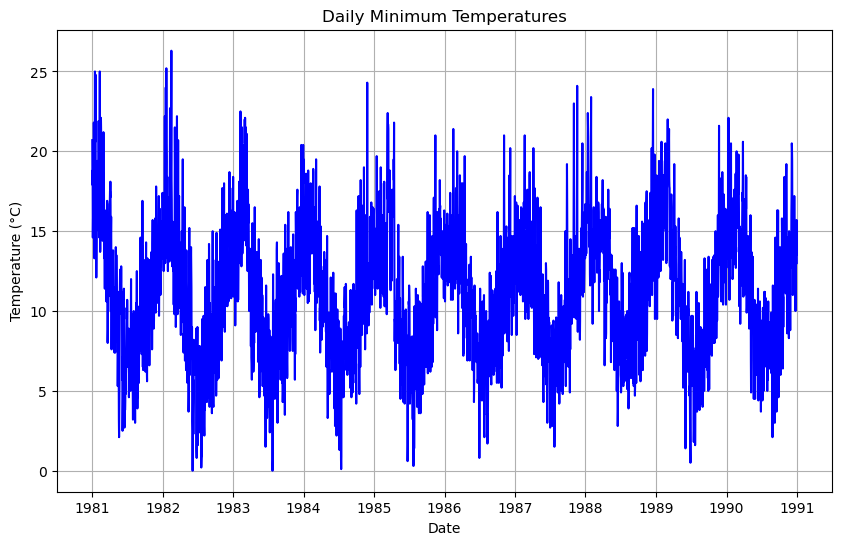

<Figure size 1200x600 with 0 Axes>

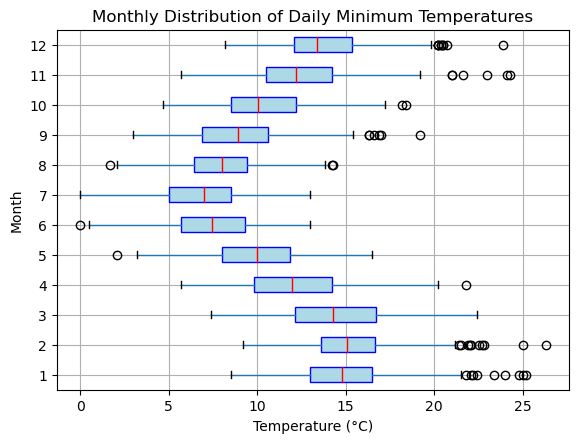

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df_temp = pd.read_csv(url)

df_temp["Date"] = pd.to_datetime(df_temp["Date"])

df_temp["Year"] = df_temp["Date"].dt.year
df_temp["Month"] = df_temp["Date"].dt.month
df_temp["Month_name"] = df_temp["Date"].dt.month_name()

df_temp = df_temp.set_index("Date")

# Plotting the daily minimum temperatures
plt.figure(figsize=(10, 6))
plt.plot(df_temp.index, df_temp["Temp"], color='blue')
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

# Creating a boxplot
plt.figure(figsize=(12,6))
df_temp.boxplot(column='Temp', by='Month', vert=False, patch_artist=True, 
               boxprops=dict(facecolor='lightblue', color='blue'),
               medianprops=dict(color='red'))
plt.title('Monthly Distribution of Daily Minimum Temperatures')
plt.suptitle('')
plt.xlabel('Temperature (°C)')
plt.ylabel('Month')
plt.grid(True)
plt.show()

### 4. Task - Creating a Heatmap by Year and Month
Create a table and chart that show the average minimum temperature by year and month.

**Task:**
- Create a pivot table using years and months.
- Display the result as a heatmap.

**Think about:**
- What patterns can you see in the heatmap?
- Are there similar periods across different years?

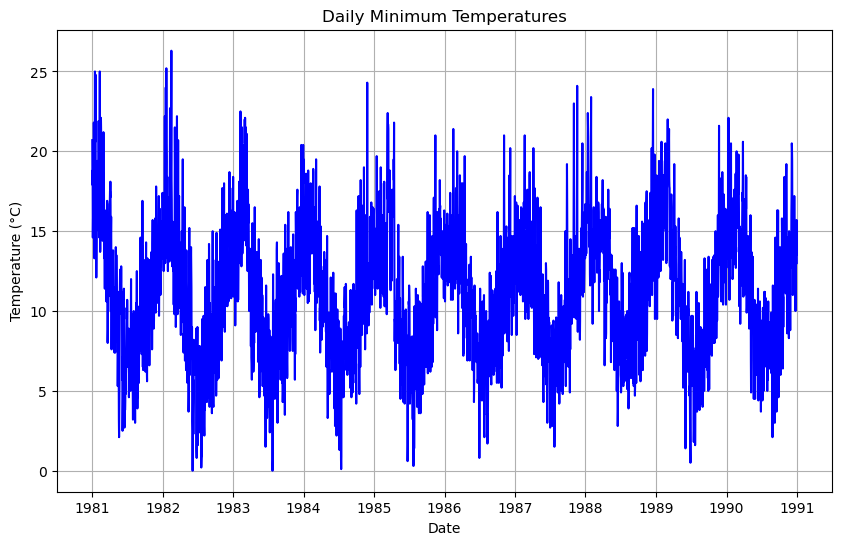

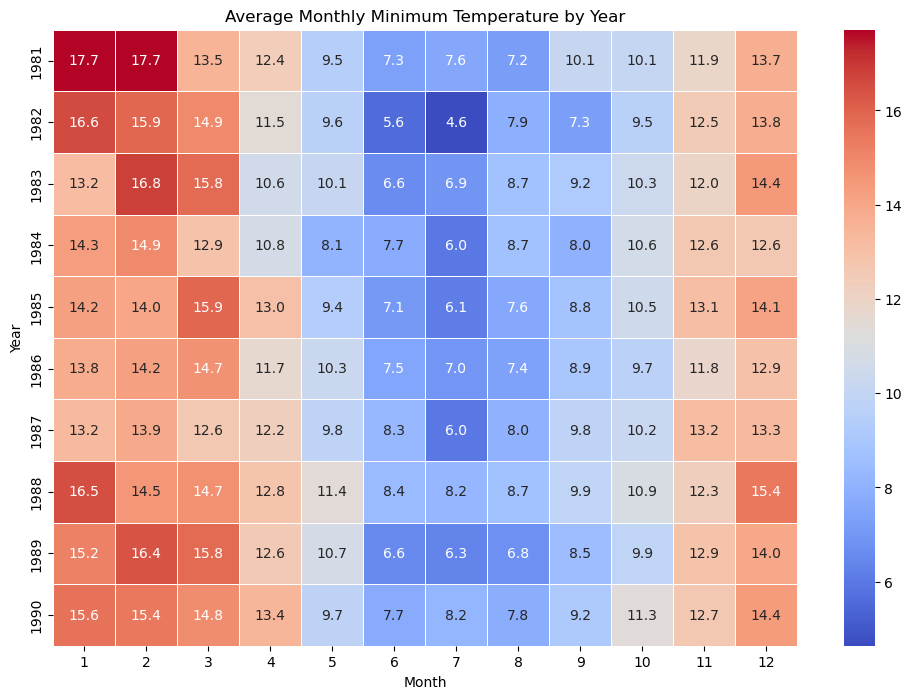

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df_temp = pd.read_csv(url)

df_temp["Date"] = pd.to_datetime(df_temp["Date"])

df_temp["Year"] = df_temp["Date"].dt.year
df_temp["Month"] = df_temp["Date"].dt.month
df_temp["Month_name"] = df_temp["Date"].dt.month_name()

df_temp = df_temp.set_index("Date")

# Plotting the daily minimum temperatures
plt.figure(figsize=(10, 6))
plt.plot(df_temp.index, df_temp["Temp"], color='blue')
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()
import seaborn as sns

# Create a pivot table for average temperature by year and month
pivot_table = df_temp.pivot_table(values='Temp', index='Year', columns='Month', aggfunc='mean')

# Plotting the heatmap
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.1f', linewidths=0.5)
plt.title('Average Monthly Minimum Temperature by Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

### 5. Task - Examining Autocorrelation
Create an autocorrelation plot for the time series.

**Think about:**
- Does the time series show temporal dependence?
- Is a repeating period visible?
- Is this consistent with what you saw in the earlier plots?

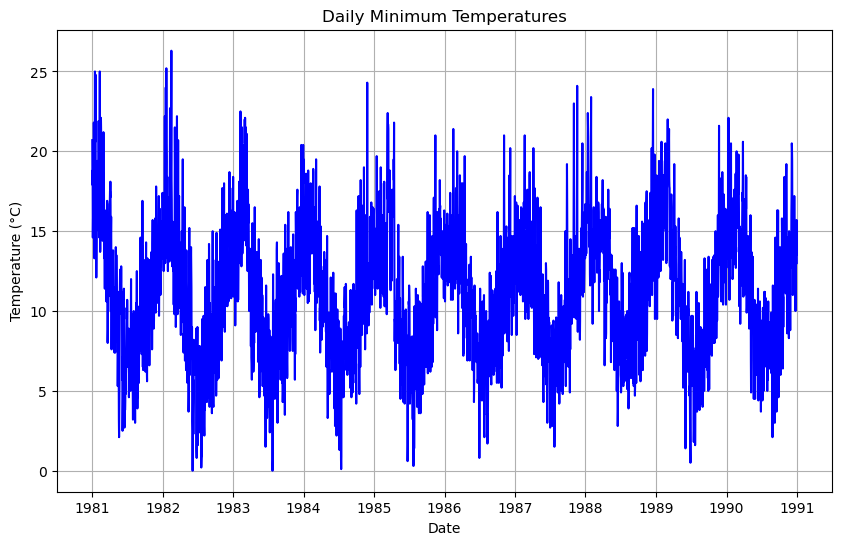

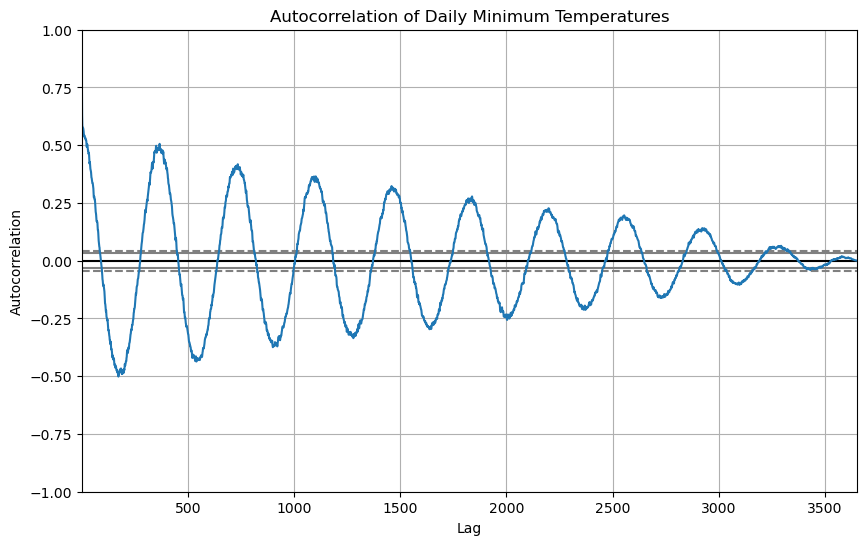

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset from GitHub
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df_temp = pd.read_csv(url)

# Convert the date column to datetime
df_temp["Date"] = pd.to_datetime(df_temp["Date"])

# Create additional time-based columns
df_temp["Year"] = df_temp["Date"].dt.year
df_temp["Month"] = df_temp["Date"].dt.month
df_temp["Month_name"] = df_temp["Date"].dt.month_name()

# Set the date column as index
df_temp = df_temp.set_index("Date")

# Plotting the daily minimum temperatures
plt.figure(figsize=(10, 6))
plt.plot(df_temp.index, df_temp["Temp"], color='blue')
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()
from pandas.plotting import autocorrelation_plot

# Create an autocorrelation plot
plt.figure(figsize=(10,6))
autocorrelation_plot(df_temp['Temp'])
plt.title('Autocorrelation of Daily Minimum Temperatures')
plt.show()